# DBSCAN 3-Feature Clustering Model - Load and Apply with PCA

This notebook loads the pre-trained DBSCAN clustering model with 3 features:
- **SST** (Sea Surface Temperature)
- **Chlorophyll-a** (log-transformed)
- **CDOM Spectral Slope** (S_275:295 or S_300:600)

**Features:**
- Load trained 3-feature DBSCAN model from pickle file
- Apply clustering to new time periods
- **PCA visualization** of 3D feature space
- Visualize clusters on maps
- Analyze cluster characteristics
- Support for both S_275:295 and S_300:600 CDOM slope types

## 1. Setup and Imports

In [81]:
import glob
import os
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import xarray as xr
from scipy.stats import binned_statistic_2d
from scipy.interpolate import RegularGridInterpolator
import pickle
import pandas as pd
from matplotlib.colors import ListedColormap, BoundaryNorm, rgb2hex
from sklearn.decomposition import PCA
import cmocean

import sys
sys.dont_write_bytecode = True
sys.path.append(os.path.abspath(".."))

from pipelines.l3_pipeline import L3DatasetLoader
from pipelines.l2_pipeline import L2DatasetLoader, GPUDataExtractor

import warnings
warnings.filterwarnings('ignore')

print("✓ Libraries imported successfully")

✓ Libraries imported successfully


## 2. Load Trained 3-Feature Model

In [82]:
# Load the trained 3-feature DBSCAN model
# Change the filename to match your trained model
slope_type = 'S300_600'  # or 'S275_295'
model_path = rf"E:\satdata\Custom\dbscan_model_3f_{slope_type}_2010_2011.pkl"

print("Loading trained 3-feature model...")
with open(model_path, 'rb') as f:
    model_data = pickle.load(f)

# Extract model components
dbscan = model_data['dbscan_model']
scaler = model_data['scaler']
lat_centers = model_data['lat_centers']
lon_centers = model_data['lon_centers']
lat_edges = model_data['lat_edges']
lon_edges = model_data['lon_edges']
bbox = model_data['bbox']
grid_shape = model_data['grid_shape']
eps = model_data['eps']
min_samples = model_data['min_samples']
n_clusters = model_data['n_clusters']
training_years = model_data['training_years']
slope_description = model_data['slope_description']
cdom_coefficients = model_data['cdom_coefficients']
n_features = model_data['n_features']

lon_min, lon_max, lat_min, lat_max = bbox
lat_bins, lon_bins = grid_shape

print("\n" + "=" * 80)
print("MODEL INFORMATION")
print("=" * 80)
print(f"  Training period: {training_years[0]}-{training_years[-1]} (June-November)")
print(f"  Region: [{lon_min}, {lat_min}] to [{lon_max}, {lat_max}]")
print(f"  Grid: {lat_bins} x {lon_bins}")
print(f"  Number of features: {n_features}")
print(f"  CDOM Slope Type: {slope_description}")
print(f"  DBSCAN parameters: eps={eps:.4f}, min_samples={min_samples}")
print(f"  Clusters found: {n_clusters}")
print(f"  Noise points: {model_data['n_noise']} ({100*model_data['n_noise']/len(model_data['training_labels']):.1f}%)")
print("=" * 80)

Loading trained 3-feature model...

MODEL INFORMATION
  Training period: 2010-2011 (June-November)
  Region: [-94.0, 27.5] to [-88.0, 30.5]
  Grid: 200 x 300
  Number of features: 3
  CDOM Slope Type: S_300:600 nm⁻¹
  DBSCAN parameters: eps=0.0807, min_samples=4
  Clusters found: 7
  Noise points: 159 (0.5%)


## 3. Visualize Training Data Clusters with PCA

In [83]:
# Recreate cluster map from training data
training_labels = model_data['training_labels']
training_sst = model_data['training_sst']
training_chlor = model_data['training_chlor']
training_cdom_slope = model_data['training_cdom_slope']

# Create colormap for clusters
unique_labels = sorted(set(training_labels))
cluster_labels = [l for l in unique_labels if l != -1]
cluster_labels_sorted = sorted(cluster_labels)

# Use viridis colormap for all clusters
palette_colors = plt.cm.viridis(np.linspace(0, 1, len(cluster_labels_sorted)))
palette = [rgb2hex(c) for c in palette_colors]

cmap_colors = ['#808080'] + palette[:len(cluster_labels_sorted)]
cmap = ListedColormap(cmap_colors)
bounds = np.arange(0, len(cluster_labels_sorted) + 2) - 0.5
norm = BoundaryNorm(bounds, cmap.N)

# Map labels to plot indices (noise=0, clusters=1,2,3...)
label_to_idx = {-1: 0}
for i, cl in enumerate(cluster_labels_sorted):
    label_to_idx[cl] = i + 1

print(f"Cluster mapping: {label_to_idx}")

Cluster mapping: {-1: 0, np.int64(0): 1, np.int64(1): 2, np.int64(2): 3, np.int64(3): 4, np.int64(4): 5, np.int64(5): 6, np.int64(6): 7}


In [84]:
# Perform PCA on training features for 2D visualization
print("\nPerforming PCA on 3D feature space...")

# Create feature matrix (same as training)
training_features = np.column_stack([training_sst, np.log10(training_chlor), training_cdom_slope])
training_features_scaled = scaler.transform(training_features)

# Fit PCA
pca = PCA(n_components=2)
training_pca = pca.fit_transform(training_features_scaled)

print(f"  PCA explained variance ratio: {pca.explained_variance_ratio_}")
print(f"  Total variance explained: {pca.explained_variance_ratio_.sum():.2%}")
print(f"\n  PCA components (feature loadings):")
print(f"    PC1: SST={pca.components_[0,0]:.3f}, log10(Chlor)={pca.components_[0,1]:.3f}, CDOM_Slope={pca.components_[0,2]:.3f}")
print(f"    PC2: SST={pca.components_[1,0]:.3f}, log10(Chlor)={pca.components_[1,1]:.3f}, CDOM_Slope={pca.components_[1,2]:.3f}")


Performing PCA on 3D feature space...
  PCA explained variance ratio: [0.94189827 0.04955383]
  Total variance explained: 99.15%

  PCA components (feature loadings):
    PC1: SST=0.564, log10(Chlor)=-0.582, CDOM_Slope=0.586
    PC2: SST=0.822, log10(Chlor)=0.466, CDOM_Slope=-0.328


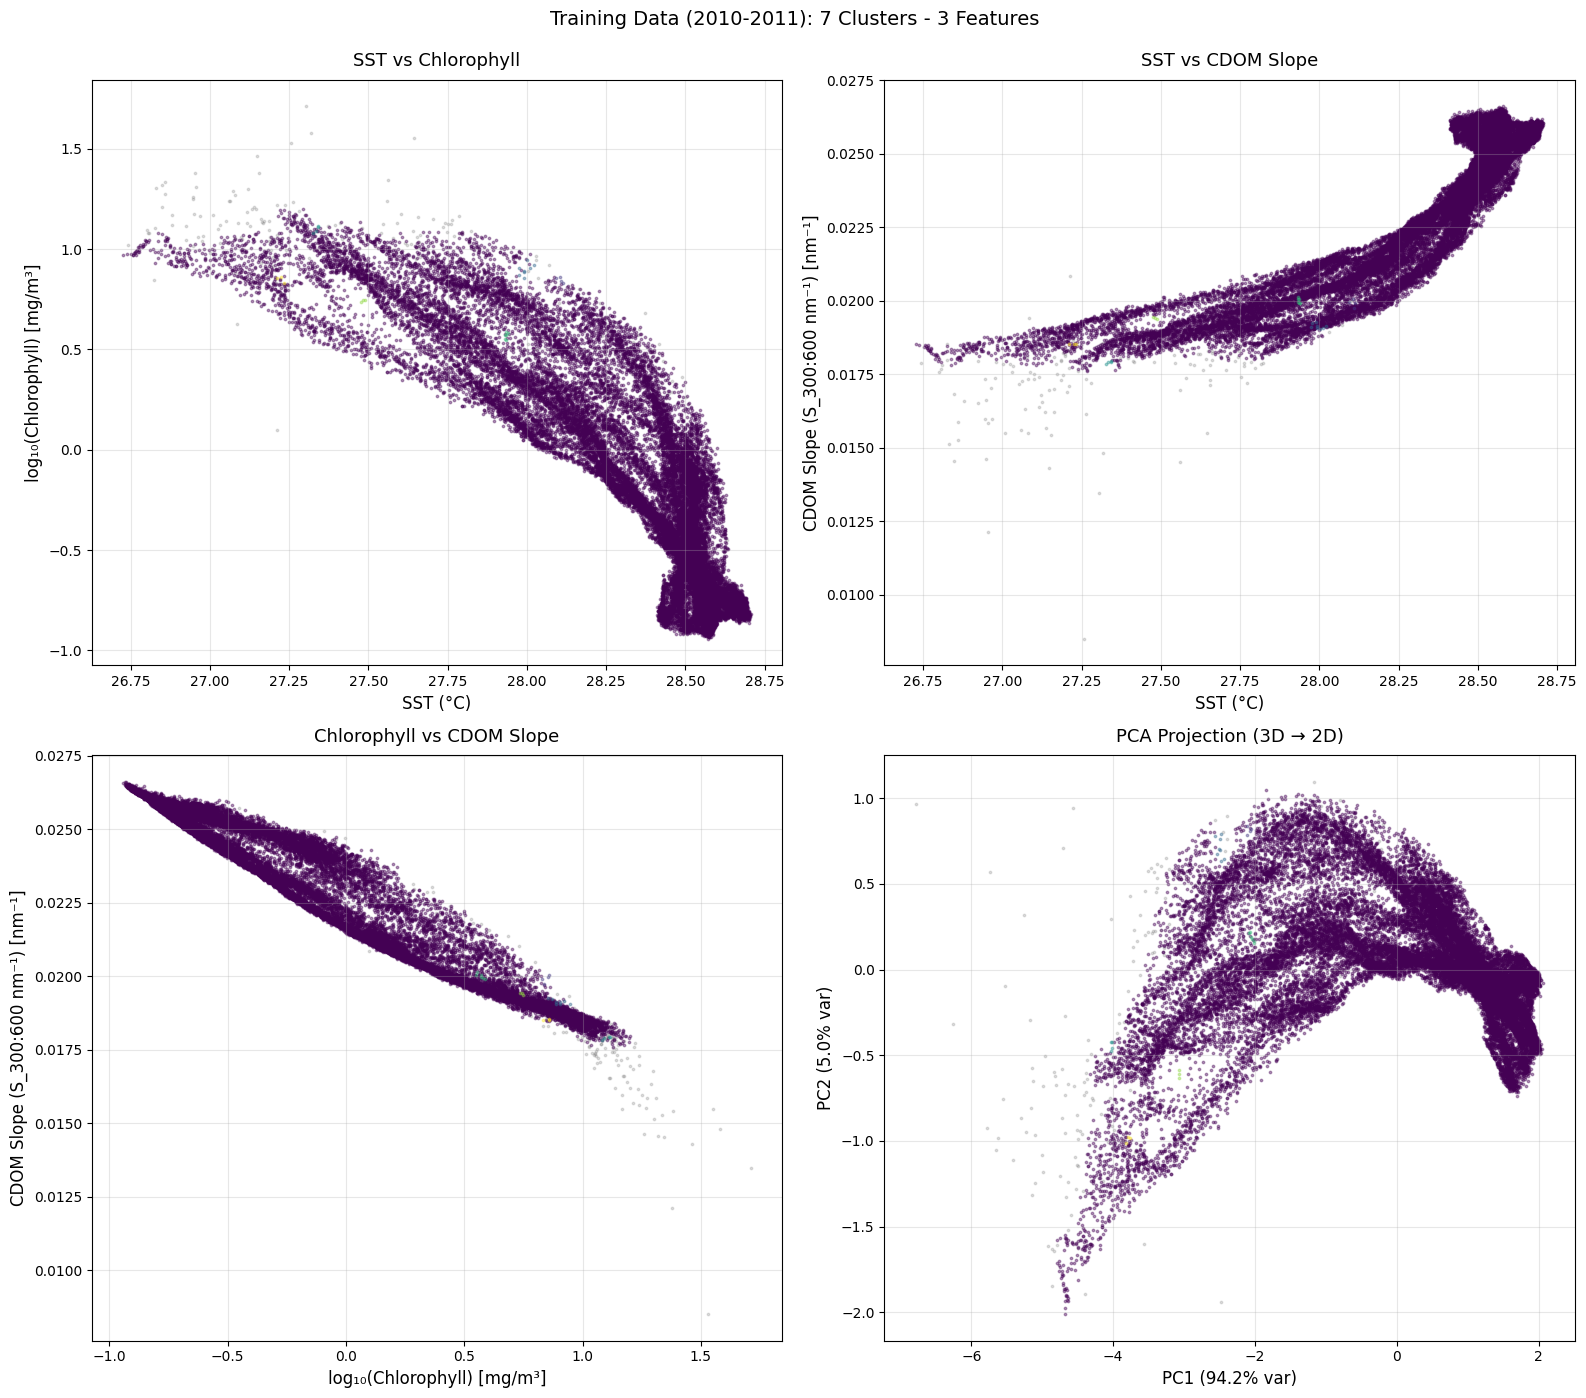

In [85]:
# Visualize feature space with PCA
fig, axes = plt.subplots(2, 2, figsize=(16, 14))

colors_map = {-1: '#808080'}
for i, cl in enumerate(cluster_labels_sorted):
    colors_map[cl] = palette[i]

# Top left: SST vs log10(Chlorophyll)
for cl in unique_labels:
    mask = training_labels == cl
    color = colors_map.get(cl, '#000000')
    label_text = 'Noise' if cl == -1 else f'Cluster {cl}'
    axes[0,0].scatter(training_sst[mask], np.log10(training_chlor[mask]), 
                    alpha=0.4 if cl != -1 else 0.25, s=3, color=color, label=label_text)

axes[0,0].set_xlabel('SST (°C)', fontsize=12)
axes[0,0].set_ylabel('log₁₀(Chlorophyll) [mg/m³]', fontsize=12)
axes[0,0].set_title('SST vs Chlorophyll', fontsize=13, pad=10)
axes[0,0].grid(True, alpha=0.3)

# Top right: SST vs CDOM Slope
for cl in unique_labels:
    mask = training_labels == cl
    color = colors_map.get(cl, '#000000')
    axes[0,1].scatter(training_sst[mask], training_cdom_slope[mask], 
                    alpha=0.4 if cl != -1 else 0.25, s=3, color=color)

axes[0,1].set_xlabel('SST (°C)', fontsize=12)
axes[0,1].set_ylabel(f'CDOM Slope ({slope_description}) [nm⁻¹]', fontsize=12)
axes[0,1].set_title('SST vs CDOM Slope', fontsize=13, pad=10)
axes[0,1].grid(True, alpha=0.3)

# Bottom left: log10(Chlorophyll) vs CDOM Slope
for cl in unique_labels:
    mask = training_labels == cl
    color = colors_map.get(cl, '#000000')
    axes[1,0].scatter(np.log10(training_chlor[mask]), training_cdom_slope[mask], 
                    alpha=0.4 if cl != -1 else 0.25, s=3, color=color)

axes[1,0].set_xlabel('log₁₀(Chlorophyll) [mg/m³]', fontsize=12)
axes[1,0].set_ylabel(f'CDOM Slope ({slope_description}) [nm⁻¹]', fontsize=12)
axes[1,0].set_title('Chlorophyll vs CDOM Slope', fontsize=13, pad=10)
axes[1,0].grid(True, alpha=0.3)

# Bottom right: PCA projection (2D)
for cl in unique_labels:
    mask = training_labels == cl
    color = colors_map.get(cl, '#000000')
    axes[1,1].scatter(training_pca[mask, 0], training_pca[mask, 1], 
                    alpha=0.4 if cl != -1 else 0.25, s=3, color=color)

axes[1,1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} var)', fontsize=12)
axes[1,1].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} var)', fontsize=12)
axes[1,1].set_title('PCA Projection (3D → 2D)', fontsize=13, pad=10)
axes[1,1].grid(True, alpha=0.3)

plt.suptitle(f'Training Data ({training_years[0]}-{training_years[-1]}): {n_clusters} Clusters - 3 Features', 
             fontsize=14, y=0.995)
plt.tight_layout()
plt.show()

In [86]:
# Print detailed cluster statistics
print("\n" + "=" * 80)
print("TRAINING DATA CLUSTER STATISTICS (3 FEATURES)")
print("=" * 80)

for label in sorted(set(training_labels)):
    mask = training_labels == label
    sst_cluster = training_sst[mask]
    chlor_cluster = training_chlor[mask]
    slope_cluster = training_cdom_slope[mask]
    
    if label == -1:
        print(f"\n⚪ Noise Points:")
    else:
        print(f"\n🔵 Cluster {label}:")
    
    print(f"  Pixels: {mask.sum():,} ({100*mask.sum()/len(mask):.1f}%)")
    print(f"  SST: {sst_cluster.mean():.2f} ± {sst_cluster.std():.2f} °C")
    print(f"       Range: [{sst_cluster.min():.2f}, {sst_cluster.max():.2f}] °C")
    print(f"  Chlorophyll: {chlor_cluster.mean():.6f} ± {chlor_cluster.std():.6f} mg/m³")
    print(f"               Range: [{chlor_cluster.min():.6f}, {chlor_cluster.max():.6f}] mg/m³")
    print(f"  CDOM Slope: {slope_cluster.mean():.6f} ± {slope_cluster.std():.6f} nm⁻¹")
    print(f"              Range: [{slope_cluster.min():.6f}, {slope_cluster.max():.6f}] nm⁻¹")

print("\n" + "=" * 80)


TRAINING DATA CLUSTER STATISTICS (3 FEATURES)

⚪ Noise Points:
  Pixels: 159 (0.5%)
  SST: 27.52 ± 0.53 °C
       Range: [26.74, 28.63] °C
  Chlorophyll: 11.309121 ± 7.328403 mg/m³
               Range: [0.352285, 51.412067] mg/m³
  CDOM Slope: 0.018359 ± 0.002514 nm⁻¹
              Range: [0.008499, 0.025715] nm⁻¹

🔵 Cluster 0:
  Pixels: 30,243 (99.4%)
  SST: 28.30 ± 0.36 °C
       Range: [26.73, 28.71] °C
  Chlorophyll: 1.614987 ± 2.379371 mg/m³
               Range: [0.114499, 15.920558] mg/m³
  CDOM Slope: 0.023147 ± 0.002475 nm⁻¹
              Range: [0.017604, 0.026610] nm⁻¹

🔵 Cluster 1:
  Pixels: 4 (0.0%)
  SST: 28.11 ± 0.01 °C
       Range: [28.09, 28.11] °C
  Chlorophyll: 7.017631 ± 0.194459 mg/m³
               Range: [6.762063, 7.248770] mg/m³
  CDOM Slope: 0.019922 ± 0.000110 nm⁻¹
              Range: [0.019750, 0.020050] nm⁻¹

🔵 Cluster 2:
  Pixels: 8 (0.0%)
  SST: 28.00 ± 0.02 °C
       Range: [27.97, 28.02] °C
  Chlorophyll: 7.905668 ± 0.493402 mg/m³
               Ran

## 4. Helper Function: Calculate CDOM Slope

This function implements the Mannino et al. MLR algorithm for CDOM spectral slope calculation.

In [87]:
def calculate_cdom_slope(rrs_443, rrs_547, coeffs):
    """
    Calculate CDOM spectral slope using Mannino et al. MLR algorithm.
    
    Parameters:
    -----------
    rrs_443 : np.ndarray
        Remote sensing reflectance at 443 nm
    rrs_547 : np.ndarray
        Remote sensing reflectance at 547 nm
    coeffs : dict
        Coefficients dictionary with B0, B1, B2
    
    Returns:
    --------
    np.ndarray
        CDOM spectral slope values in nm⁻¹
    """
    # Initialize with NaN
    cdom_slope = np.full_like(rrs_443, np.nan, dtype=float)
    
    # Mask for valid data (positive values, no NaNs)
    valid_mask = (~np.isnan(rrs_443) & ~np.isnan(rrs_547) & 
                  (rrs_443 > 0) & (rrs_547 > 0))
    
    if np.any(valid_mask):
        # Apply Mannino et al. MLR algorithm
        # Ln[S] = B0 + B1 × Ln[Rrs(443)] + B2 × Ln[Rrs(547)]
        ln_rrs_443 = np.log(rrs_443[valid_mask])
        ln_rrs_547 = np.log(rrs_547[valid_mask])
        
        ln_slope = (coeffs['B0'] + 
                   coeffs['B1'] * ln_rrs_443 + 
                   coeffs['B2'] * ln_rrs_547)
        
        # Convert back to linear space: S = exp(Ln[S])
        cdom_slope[valid_mask] = np.exp(ln_slope)
    
    return cdom_slope

print("✓ CDOM slope calculation function defined")

✓ CDOM slope calculation function defined


## 5. Apply Model to New Data

Select a time period to apply the trained clustering model.

In [88]:
# Configuration for new data
apply_year = 2024
apply_start = '2024-06-01'
apply_end = '2024-06-07'

sst_var = 'analysed_sst'
chlor_var = 'chlor_a'
chlor_group = 'geophysical_data'
rrs_vars = ['Rrs_443', 'Rrs_547']
rrs_group = 'geophysical_data'

sst_base_pattern = r"E:\satdata\MUR-JPL-L4-GLOB-v4.1_Texas Louisiana Shelf_{year}-06-01_{year}-11-30"
chlor_base_pattern = r"E:\satdata\Texas Louisiana Shelf_{year}-06-01_{year}-11-30"
rrs_base_pattern = r"E:\satdata\Texas Louisiana Shelf_{year}-06-01_{year}-11-30"  # Same as chlor

print(f"Applying model to: {apply_start} to {apply_end}")

Applying model to: 2024-06-01 to 2024-06-07


In [89]:
# Load SST data for the period
print("\n" + "=" * 80)
print("LOADING SST DATA")
print("=" * 80)

sst_dir = sst_base_pattern.format(year=apply_year)
all_sst_files = sorted(glob.glob(os.path.join(sst_dir, '*.nc')))
print(f"  Total SST files in {apply_year}: {len(all_sst_files)}")

# Filter by date
sst_files = []
for sst_file in all_sst_files:
    try:
        with xr.open_dataset(sst_file) as ds:
            file_time = pd.to_datetime(ds.time.values[0])
            if pd.Timestamp(apply_start) <= file_time <= pd.Timestamp(apply_end):
                sst_files.append(sst_file)
    except:
        continue

print(f"  Files in period: {len(sst_files)}")

if len(sst_files) > 0:
    # Load datasets
    sst_loader = L3DatasetLoader(variables=[sst_var], bbox=(lon_min, lon_max, lat_min, lat_max))
    sst_datasets = sst_loader.load_multiple(sst_files)

    # Process SST
    sst_list = []
    for ds in sst_datasets:
        sst_k = ds[sst_var].values.squeeze()
        sst_c = sst_k - 273.15
        sst_c[(sst_c < -2) | (sst_c > 35)] = np.nan
        sst_list.append(sst_c)

    sst_mean = np.nanmean(np.stack(sst_list, axis=0), axis=0)
    lat_sst = sst_datasets[0]['lat'].values
    lon_sst = sst_datasets[0]['lon'].values

    print(f"  SST range: {np.nanmin(sst_mean):.2f} to {np.nanmax(sst_mean):.2f} °C")
    print(f"  Valid pixels: {np.sum(~np.isnan(sst_mean))}")
else:
    print("  ⚠ No SST files found")
    sst_mean = None


LOADING SST DATA
  Total SST files in 2024: 0
  Files in period: 0
  ⚠ No SST files found


In [90]:
# Load chlorophyll data for the period
print("\n" + "=" * 80)
print("LOADING CHLOROPHYLL DATA")
print("=" * 80)

chlor_dir = chlor_base_pattern.format(year=apply_year)
all_chlor_files = glob.glob(os.path.join(chlor_dir, '**', '*.nc'), recursive=True)
print(f"  Total chlorophyll files in {apply_year}: {len(all_chlor_files)}")

# Filter by date (from filename)
chlor_files = []
for chlor_file in all_chlor_files:
    filename = os.path.basename(chlor_file)
    try:
        if 'AQUA_MODIS' in filename or 'MODIS' in filename:
            parts = filename.split('.')
            if len(parts) > 1:
                date_str = parts[1][:8]
                file_date = pd.to_datetime(date_str, format='%Y%m%d')
                if pd.Timestamp(apply_start) <= file_date <= pd.Timestamp(apply_end):
                    chlor_files.append(chlor_file)
    except:
        continue

print(f"  Files in period: {len(chlor_files)}")

if len(chlor_files) > 0:
    # Load datasets
    chlor_loader = L2DatasetLoader(variables=[chlor_var], group=chlor_group)
    chlor_datasets = chlor_loader.load_multiple(chlor_files)
    
    # Extract data
    try:
        extractor = GPUDataExtractor(variables=[chlor_var])
        lon_chlor, lat_chlor, chlor_data = extractor.extract(chlor_datasets)
        chlor_flat = chlor_data[chlor_var]
        print(f"  GPU extraction: {len(chlor_flat)} points")
    except Exception as e:
        print(f"  GPU failed, using CPU...")
        all_lons, all_lats, all_chlor = [], [], []
        for ds in chlor_datasets:
            lat = ds['lat'].values.flatten()
            lon = ds['lon'].values.flatten()
            chlor = ds[chlor_var].values.flatten()
            valid = (~np.isnan(lat) & ~np.isnan(lon) & ~np.isnan(chlor) & (chlor > 0))
            all_lats.extend(lat[valid])
            all_lons.extend(lon[valid])
            all_chlor.extend(chlor[valid])
        lat_chlor = np.array(all_lats)
        lon_chlor = np.array(all_lons)
        chlor_flat = np.array(all_chlor)
        print(f"  CPU extraction: {len(chlor_flat)} points")
else:
    print("  ⚠ No chlorophyll files found")
    chlor_flat = np.array([])
    lat_chlor = np.array([])
    lon_chlor = np.array([])


LOADING CHLOROPHYLL DATA
  Total chlorophyll files in 2024: 0
  Files in period: 0
  ⚠ No chlorophyll files found


In [91]:
# Load RRS data for CDOM slope calculation
print("\n" + "=" * 80)
print("LOADING RRS DATA FOR CDOM SLOPE")
print("=" * 80)

rrs_dir = rrs_base_pattern.format(year=apply_year)
all_rrs_files = glob.glob(os.path.join(rrs_dir, '**', '*.nc'), recursive=True)
print(f"  Total RRS files in {apply_year}: {len(all_rrs_files)}")

# Filter by date (same logic as chlorophyll)
rrs_files = []
for rrs_file in all_rrs_files:
    filename = os.path.basename(rrs_file)
    try:
        if 'AQUA_MODIS' in filename or 'MODIS' in filename:
            parts = filename.split('.')
            if len(parts) > 1:
                date_str = parts[1][:8]
                file_date = pd.to_datetime(date_str, format='%Y%m%d')
                if pd.Timestamp(apply_start) <= file_date <= pd.Timestamp(apply_end):
                    rrs_files.append(rrs_file)
    except:
        continue

print(f"  Files in period: {len(rrs_files)}")

if len(rrs_files) > 0:
    # Load datasets
    rrs_loader = L2DatasetLoader(variables=rrs_vars, group=rrs_group)
    rrs_datasets = rrs_loader.load_multiple(rrs_files)
    
    # Extract RRS data
    try:
        rrs_extractor = GPUDataExtractor(variables=rrs_vars)
        lon_rrs, lat_rrs, rrs_data = rrs_extractor.extract(rrs_datasets)
        rrs_443_flat = rrs_data['Rrs_443']
        rrs_547_flat = rrs_data['Rrs_547']
        print(f"  GPU extraction: {len(rrs_443_flat)} points")
    except Exception as e:
        print(f"  GPU failed, using CPU...")
        all_lons_rrs, all_lats_rrs, all_rrs_443, all_rrs_547 = [], [], [], []
        for ds in rrs_datasets:
            lat = ds['lat'].values.flatten()
            lon = ds['lon'].values.flatten()
            rrs_443 = ds['Rrs_443'].values.flatten()
            rrs_547 = ds['Rrs_547'].values.flatten()
            valid = (~np.isnan(lat) & ~np.isnan(lon) & 
                    ~np.isnan(rrs_443) & ~np.isnan(rrs_547) & 
                    (rrs_443 > 0) & (rrs_547 > 0))
            all_lats_rrs.extend(lat[valid])
            all_lons_rrs.extend(lon[valid])
            all_rrs_443.extend(rrs_443[valid])
            all_rrs_547.extend(rrs_547[valid])
        lat_rrs = np.array(all_lats_rrs)
        lon_rrs = np.array(all_lons_rrs)
        rrs_443_flat = np.array(all_rrs_443)
        rrs_547_flat = np.array(all_rrs_547)
        print(f"  CPU extraction: {len(rrs_443_flat)} points")
    
    # Calculate CDOM slope
    print(f"  Calculating CDOM spectral slope ({slope_description})...")
    cdom_slope_flat = calculate_cdom_slope(rrs_443_flat, rrs_547_flat, cdom_coefficients)
    valid_slope_count = np.sum(~np.isnan(cdom_slope_flat))
    print(f"  Valid CDOM slope values: {valid_slope_count}")
    if valid_slope_count > 0:
        print(f"  CDOM slope range: {np.nanmin(cdom_slope_flat):.6f} to {np.nanmax(cdom_slope_flat):.6f} nm⁻¹")
else:
    print("  ⚠ No RRS files found")
    cdom_slope_flat = np.array([])
    lat_rrs = np.array([])
    lon_rrs = np.array([])


LOADING RRS DATA FOR CDOM SLOPE
  Total RRS files in 2024: 0
  Files in period: 0
  ⚠ No RRS files found


In [92]:
# Grid the data
print("\n" + "=" * 80)
print("GRIDDING DATA")
print("=" * 80)

if len(chlor_flat) > 0 and len(cdom_slope_flat) > 0 and sst_mean is not None:
    # Bin chlorophyll
    clip_mask_chlor = ((lon_chlor >= lon_min) & (lon_chlor <= lon_max) &
                       (lat_chlor >= lat_min) & (lat_chlor <= lat_max))

    chlor_binned, _, _, _ = binned_statistic_2d(
        lat_chlor[clip_mask_chlor], lon_chlor[clip_mask_chlor], chlor_flat[clip_mask_chlor],
        statistic='mean',
        bins=[lat_bins, lon_bins],
        range=[[lat_min, lat_max], [lon_min, lon_max]]
    )

    print(f"  Valid chlorophyll pixels: {np.sum(~np.isnan(chlor_binned))}")

    # Bin CDOM slope
    clip_mask_rrs = ((lon_rrs >= lon_min) & (lon_rrs <= lon_max) &
                     (lat_rrs >= lat_min) & (lat_rrs <= lat_max))

    cdom_slope_binned, _, _, _ = binned_statistic_2d(
        lat_rrs[clip_mask_rrs], lon_rrs[clip_mask_rrs], cdom_slope_flat[clip_mask_rrs],
        statistic='mean',
        bins=[lat_bins, lon_bins],
        range=[[lat_min, lat_max], [lon_min, lon_max]]
    )

    print(f"  Valid CDOM slope pixels: {np.sum(~np.isnan(cdom_slope_binned))}")

    # Interpolate SST
    sst_interpolator = RegularGridInterpolator(
        (lat_sst, lon_sst), sst_mean,
        method='linear', bounds_error=False, fill_value=np.nan
    )

    lon_grid, lat_grid = np.meshgrid(lon_centers, lat_centers)
    points = np.column_stack([lat_grid.ravel(), lon_grid.ravel()])
    sst_regridded = sst_interpolator(points).reshape(chlor_binned.shape)

    print(f"  Valid SST pixels: {np.sum(~np.isnan(sst_regridded))}")
else:
    print("  ⚠ Insufficient data for gridding")
    chlor_binned = None
    cdom_slope_binned = None
    sst_regridded = None


GRIDDING DATA
  ⚠ Insufficient data for gridding


In [93]:
# Apply clustering model
print("\n" + "=" * 80)
print("APPLYING 3-FEATURE CLUSTERING MODEL")
print("=" * 80)

if sst_regridded is not None and chlor_binned is not None and cdom_slope_binned is not None:
    valid_mask = (~np.isnan(sst_regridded) & ~np.isnan(chlor_binned) & ~np.isnan(cdom_slope_binned))
    n_valid = np.sum(valid_mask)
    print(f"  Pixels with SST, chlorophyll, and CDOM slope: {n_valid}")

    if n_valid > 0:
        sst_valid = sst_regridded[valid_mask]
        chlor_valid = chlor_binned[valid_mask]
        cdom_slope_valid = cdom_slope_binned[valid_mask]
        
        # Create features (3D)
        features = np.column_stack([sst_valid, np.log10(chlor_valid), cdom_slope_valid])
        features_scaled = scaler.transform(features)
        
        # Predict clusters
        labels = dbscan.fit_predict(features_scaled)
        
        n_clusters_found = len(set(labels)) - (1 if -1 in labels else 0)
        n_noise = np.sum(labels == -1)
        
        print(f"  Clusters found: {n_clusters_found}")
        print(f"  Noise points: {n_noise} ({100*n_noise/len(labels):.1f}%)")
        
        # Create cluster map
        cluster_map = np.full(sst_regridded.shape, np.nan)
        cluster_map[valid_mask] = labels
        
        # Perform PCA on new data
        new_pca = pca.transform(features_scaled)
    else:
        print("  ⚠ No valid data to cluster")
        labels = np.array([])
        cluster_map = np.full((lat_bins, lon_bins), np.nan)
        new_pca = None
else:
    print("  ⚠ No gridded data available")
    labels = np.array([])
    cluster_map = np.full((lat_bins, lon_bins), np.nan)
    n_valid = 0
    new_pca = None


APPLYING 3-FEATURE CLUSTERING MODEL
  ⚠ No gridded data available


## 6. Visualize Results with PCA

In [94]:
if n_valid > 0:
    fig, ax = plt.subplots(1, 1, figsize=(10, 7), subplot_kw={'projection': ccrs.PlateCarree()})

    # Prepare plot data
    unique_labels_new = sorted(set(labels))
    cluster_labels_new = [l for l in unique_labels_new if l != -1]
    cluster_labels_sorted_new = sorted(cluster_labels_new)

    plot_map = np.full_like(cluster_map, np.nan)
    if len(cluster_labels_sorted_new) > 0:
        plot_map[valid_mask] = np.where(
            labels == -1, 0,
            np.array([cluster_labels_sorted_new.index(l) + 1 if l in cluster_labels_sorted_new else 0 
                      for l in labels])
        )

    # Cluster map
    ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())

    cluster_plot = ax.pcolormesh(lon_edges, lat_edges, plot_map,
                                 cmap=cmap, norm=norm, shading='auto',
                                 transform=ccrs.PlateCarree())

    ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
    ax.add_feature(cfeature.LAND, facecolor='lightgray')
    ax.add_feature(cfeature.STATES, linestyle='-', edgecolor='gray', alpha=0.5)

    gl = ax.gridlines(draw_labels=True, linewidth=0.5, color='gray', alpha=0.5, linestyle='--')
    gl.top_labels = gl.right_labels = False

    plt.colorbar(cluster_plot, ax=ax, fraction=0.046, pad=0.04)
    ax.set_title(f'DBSCAN Clusters (3 Features)\n{apply_start} to {apply_end}', fontsize=12, pad=10)

    plt.tight_layout()
    plt.show()
else:
    print("No data to visualize")

No data to visualize


In [95]:
# Feature space visualization for new data with PCA
if n_valid > 0 and new_pca is not None:
    fig, axes = plt.subplots(2, 2, figsize=(16, 14))
    
    # Top left: SST vs log10(Chlorophyll)
    for cl in unique_labels_new:
        mask = labels == cl
        color = colors_map.get(cl, '#808080')
        label_text = 'Noise' if cl == -1 else f'Cluster {cl}'
        axes[0,0].scatter(sst_valid[mask], np.log10(chlor_valid[mask]), 
                        alpha=0.4 if cl != -1 else 0.25, s=4, color=color, label=label_text)
    
    axes[0,0].set_xlabel('SST (°C)', fontsize=12)
    axes[0,0].set_ylabel('log₁₀(Chlorophyll) [mg/m³]', fontsize=12)
    axes[0,0].set_title('SST vs Chlorophyll', fontsize=13, pad=10)
    axes[0,0].grid(True, alpha=0.3)
    
    # Top right: SST vs CDOM Slope
    for cl in unique_labels_new:
        mask = labels == cl
        color = colors_map.get(cl, '#808080')
        axes[0,1].scatter(sst_valid[mask], cdom_slope_valid[mask], 
                        alpha=0.4 if cl != -1 else 0.25, s=4, color=color)
    
    axes[0,1].set_xlabel('SST (°C)', fontsize=12)
    axes[0,1].set_ylabel(f'CDOM Slope ({slope_description}) [nm⁻¹]', fontsize=12)
    axes[0,1].set_title('SST vs CDOM Slope', fontsize=13, pad=10)
    axes[0,1].grid(True, alpha=0.3)
    
    # Bottom left: log10(Chlorophyll) vs CDOM Slope
    for cl in unique_labels_new:
        mask = labels == cl
        color = colors_map.get(cl, '#808080')
        axes[1,0].scatter(np.log10(chlor_valid[mask]), cdom_slope_valid[mask], 
                        alpha=0.4 if cl != -1 else 0.25, s=4, color=color)
    
    axes[1,0].set_xlabel('log₁₀(Chlorophyll) [mg/m³]', fontsize=12)
    axes[1,0].set_ylabel(f'CDOM Slope ({slope_description}) [nm⁻¹]', fontsize=12)
    axes[1,0].set_title('Chlorophyll vs CDOM Slope', fontsize=13, pad=10)
    axes[1,0].grid(True, alpha=0.3)
    
    # Bottom right: PCA projection
    for cl in unique_labels_new:
        mask = labels == cl
        color = colors_map.get(cl, '#808080')
        axes[1,1].scatter(new_pca[mask, 0], new_pca[mask, 1], 
                        alpha=0.4 if cl != -1 else 0.25, s=4, color=color)
    
    axes[1,1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} var)', fontsize=12)
    axes[1,1].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} var)', fontsize=12)
    axes[1,1].set_title('PCA Projection (3D → 2D)', fontsize=13, pad=10)
    axes[1,1].grid(True, alpha=0.3)
    
    plt.suptitle(f'Feature Space: {apply_start} to {apply_end}', 
                 fontsize=14, y=0.995)
    plt.tight_layout()
    plt.show()

In [96]:
# Print cluster statistics for new data
if n_valid > 0:
    print("\n" + "=" * 80)
    print(f"CLUSTER STATISTICS: {apply_start.upper()} TO {apply_end.upper()}")
    print("=" * 80)
    
    for label in sorted(set(labels)):
        mask = labels == label
        sst_cluster = sst_valid[mask]
        chlor_cluster = chlor_valid[mask]
        slope_cluster = cdom_slope_valid[mask]
        
        if label == -1:
            print(f"\n⚪ Noise Points:")
        else:
            print(f"\n🔵 Cluster {label}:")
        
        print(f"  Pixels: {mask.sum():,} ({100*mask.sum()/len(mask):.1f}%)")
        print(f"  SST: {sst_cluster.mean():.2f} ± {sst_cluster.std():.2f} °C")
        print(f"       Range: [{sst_cluster.min():.2f}, {sst_cluster.max():.2f}] °C")
        print(f"  Chlorophyll: {chlor_cluster.mean():.6f} ± {chlor_cluster.std():.6f} mg/m³")
        print(f"               Range: [{chlor_cluster.min():.6f}, {chlor_cluster.max():.6f}] mg/m³")
        print(f"  CDOM Slope: {slope_cluster.mean():.6f} ± {slope_cluster.std():.6f} nm⁻¹")
        print(f"              Range: [{slope_cluster.min():.6f}, {slope_cluster.max():.6f}] nm⁻¹")
    
    print("\n" + "=" * 80)

## 7. Summary

The trained 3-feature DBSCAN model can identify oceanic regimes based on SST, chlorophyll, and CDOM spectral slope patterns. The model was trained on 2010-2011 data and can be applied to any new time period with the required measurements.

**Key Features:**
- **3D Feature Space**: SST, Log10(Chlorophyll), CDOM Slope
- **PCA Visualization**: 3D features projected to 2D for visualization
- **Flexible CDOM Slope**: Supports both S_275:295 and S_300:600
- **Mannino et al. Algorithm**: Uses MLR for CDOM slope calculation

**Next Steps:**
- Apply to different time periods
- Compare with 2-feature model results
- Analyze how CDOM slope influences cluster separation
- Export cluster masks for further analysis

# DBSCAN 3-Feature Clustering Model - Load and Apply

This notebook loads the pre-trained DBSCAN clustering model (2010-2011) with **3 features** (SST, Chlorophyll, Kd_490) and applies it to new data or visualizes the training results.

**Features:**
- Load trained DBSCAN model from pickle file (3-feature version)
- Use Kd_490 (Diffuse attenuation coefficient at 490 nm)
- Apply clustering to new time periods
- Visualize clusters on maps
- Use PCA to visualize 3D feature space in 2D
- Analyze cluster characteristics

## 1. Setup and Imports

In [97]:
import glob
import os
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import xarray as xr
from scipy.stats import binned_statistic_2d
from scipy.interpolate import RegularGridInterpolator
import pickle
import pandas as pd
from matplotlib.colors import ListedColormap, BoundaryNorm, rgb2hex
from sklearn.decomposition import PCA

import sys
sys.dont_write_bytecode = True
sys.path.append(os.path.abspath(".."))

from pipelines.l3_pipeline import L3DatasetLoader
from pipelines.l2_pipeline import L2DatasetLoader, GPUDataExtractor

import warnings
warnings.filterwarnings('ignore')

print("✓ Libraries imported successfully")

✓ Libraries imported successfully


## 2. Load Trained 3-Feature Model

In [98]:
# Load the trained DBSCAN model (3 features: SST, Chlorophyll, Kd_490)
model_path = r"E:\satdata\Custom\dbscan_model_3f_2010_2011.pkl"

print("Loading trained 3-feature model...")
with open(model_path, 'rb') as f:
    model_data = pickle.load(f)

# Extract model components
dbscan = model_data['dbscan_model']
scaler = model_data['scaler']
lat_centers = model_data['lat_centers']
lon_centers = model_data['lon_centers']
lat_edges = model_data['lat_edges']
lon_edges = model_data['lon_edges']
bbox = model_data['bbox']
grid_shape = model_data['grid_shape']
eps = model_data['eps']
min_samples = model_data['min_samples']
n_clusters = model_data['n_clusters']
training_years = model_data['training_years']

# Kd_490 variable
kd_var = model_data['kd_var']

lon_min, lon_max, lat_min, lat_max = bbox
lat_bins, lon_bins = grid_shape

print("\n" + "=" * 80)
print("MODEL INFORMATION")
print("=" * 80)
print(f"  Training period: {training_years[0]}-{training_years[-1]} (June-November)")
print(f"  Region: [{lon_min}, {lat_min}] to [{lon_max}, {lat_max}]")
print(f"  Grid: {lat_bins} x {lon_bins}")
print(f"  Features: SST, Chlorophyll (log10), Kd_490")
print(f"  Kd_490: Diffuse attenuation coefficient at 490 nm (m^-1)")
print(f"  DBSCAN parameters: eps={eps:.4f}, min_samples={min_samples}")
print(f"  Clusters found: {n_clusters}")
print(f"  Noise points: {model_data['n_noise']} ({100*model_data['n_noise']/len(model_data['training_labels']):.1f}%)")
print("=" * 80)

Loading trained 3-feature model...

MODEL INFORMATION
  Training period: 2011-2011 (June-November)
  Region: [-94.0, 27.5] to [-88.0, 30.5]
  Grid: 200 x 300
  Features: SST, Chlorophyll (log10), Kd_490
  Kd_490: Diffuse attenuation coefficient at 490 nm (m^-1)
  DBSCAN parameters: eps=0.0315, min_samples=4
  Clusters found: 269
  Noise points: 5034 (11.3%)

MODEL INFORMATION
  Training period: 2011-2011 (June-November)
  Region: [-94.0, 27.5] to [-88.0, 30.5]
  Grid: 200 x 300
  Features: SST, Chlorophyll (log10), Kd_490
  Kd_490: Diffuse attenuation coefficient at 490 nm (m^-1)
  DBSCAN parameters: eps=0.0315, min_samples=4
  Clusters found: 269
  Noise points: 5034 (11.3%)


## 3. Visualize Training Data Clusters with PCA

In [99]:
# Recreate cluster map from training data
training_labels = model_data['training_labels']
training_sst = model_data['training_sst']
training_chlor = model_data['training_chlor']
training_kd = model_data['training_kd']

# Create colormap for clusters
unique_labels = sorted(set(training_labels))
cluster_labels = [l for l in unique_labels if l != -1]
cluster_labels_sorted = sorted(cluster_labels)

# Use viridis colormap for all clusters
palette_colors = plt.cm.viridis(np.linspace(0, 1, len(cluster_labels_sorted)))
palette = [rgb2hex(c) for c in palette_colors]

cmap_colors = ['#808080'] + palette[:len(cluster_labels_sorted)]
cmap = ListedColormap(cmap_colors)
bounds = np.arange(0, len(cluster_labels_sorted) + 2) - 0.5
norm = BoundaryNorm(bounds, cmap.N)

# Map labels to plot indices (noise=0, clusters=1,2,3...)
label_to_idx = {-1: 0}
for i, cl in enumerate(cluster_labels_sorted):
    label_to_idx[cl] = i + 1

print(f"Cluster mapping: {label_to_idx}")

colors_map = {-1: '#808080'}
for i, cl in enumerate(cluster_labels_sorted):
    colors_map[cl] = palette[i]

Cluster mapping: {-1: 0, np.int64(0): 1, np.int64(1): 2, np.int64(2): 3, np.int64(3): 4, np.int64(4): 5, np.int64(5): 6, np.int64(6): 7, np.int64(7): 8, np.int64(8): 9, np.int64(9): 10, np.int64(10): 11, np.int64(11): 12, np.int64(12): 13, np.int64(13): 14, np.int64(14): 15, np.int64(15): 16, np.int64(16): 17, np.int64(17): 18, np.int64(18): 19, np.int64(19): 20, np.int64(20): 21, np.int64(21): 22, np.int64(22): 23, np.int64(23): 24, np.int64(24): 25, np.int64(25): 26, np.int64(26): 27, np.int64(27): 28, np.int64(28): 29, np.int64(29): 30, np.int64(30): 31, np.int64(31): 32, np.int64(32): 33, np.int64(33): 34, np.int64(34): 35, np.int64(35): 36, np.int64(36): 37, np.int64(37): 38, np.int64(38): 39, np.int64(39): 40, np.int64(40): 41, np.int64(41): 42, np.int64(42): 43, np.int64(43): 44, np.int64(44): 45, np.int64(45): 46, np.int64(46): 47, np.int64(47): 48, np.int64(48): 49, np.int64(49): 50, np.int64(50): 51, np.int64(51): 52, np.int64(52): 53, np.int64(53): 54, np.int64(54): 55, np.i

In [100]:
# Apply PCA to visualize 3D feature space in 2D
print("Applying PCA for visualization...")

# Prepare features (same as training: SST, log10(Chlor), Kd_490)
training_features = np.column_stack([training_sst, np.log10(training_chlor), training_kd])
training_features_scaled = scaler.transform(training_features)

# Apply PCA
pca = PCA(n_components=2)
training_pca = pca.fit_transform(training_features_scaled)

print(f"PCA explained variance ratio: {pca.explained_variance_ratio_}")
print(f"Total variance explained: {pca.explained_variance_ratio_.sum():.2%}")
print(f"\nPCA components:")
print(f"  PC1: SST={pca.components_[0,0]:.3f}, log10(Chlor)={pca.components_[0,1]:.3f}, Kd_490={pca.components_[0,2]:.3f}")
print(f"  PC2: SST={pca.components_[1,0]:.3f}, log10(Chlor)={pca.components_[1,1]:.3f}, Kd_490={pca.components_[1,2]:.3f}")

Applying PCA for visualization...
PCA explained variance ratio: [0.83247383 0.11303535]
Total variance explained: 94.55%

PCA components:
  PC1: SST=-0.588, log10(Chlor)=0.590, Kd_490=0.553
  PC2: SST=0.413, log10(Chlor)=-0.370, Kd_490=0.833
PCA explained variance ratio: [0.83247383 0.11303535]
Total variance explained: 94.55%

PCA components:
  PC1: SST=-0.588, log10(Chlor)=0.590, Kd_490=0.553
  PC2: SST=0.413, log10(Chlor)=-0.370, Kd_490=0.833


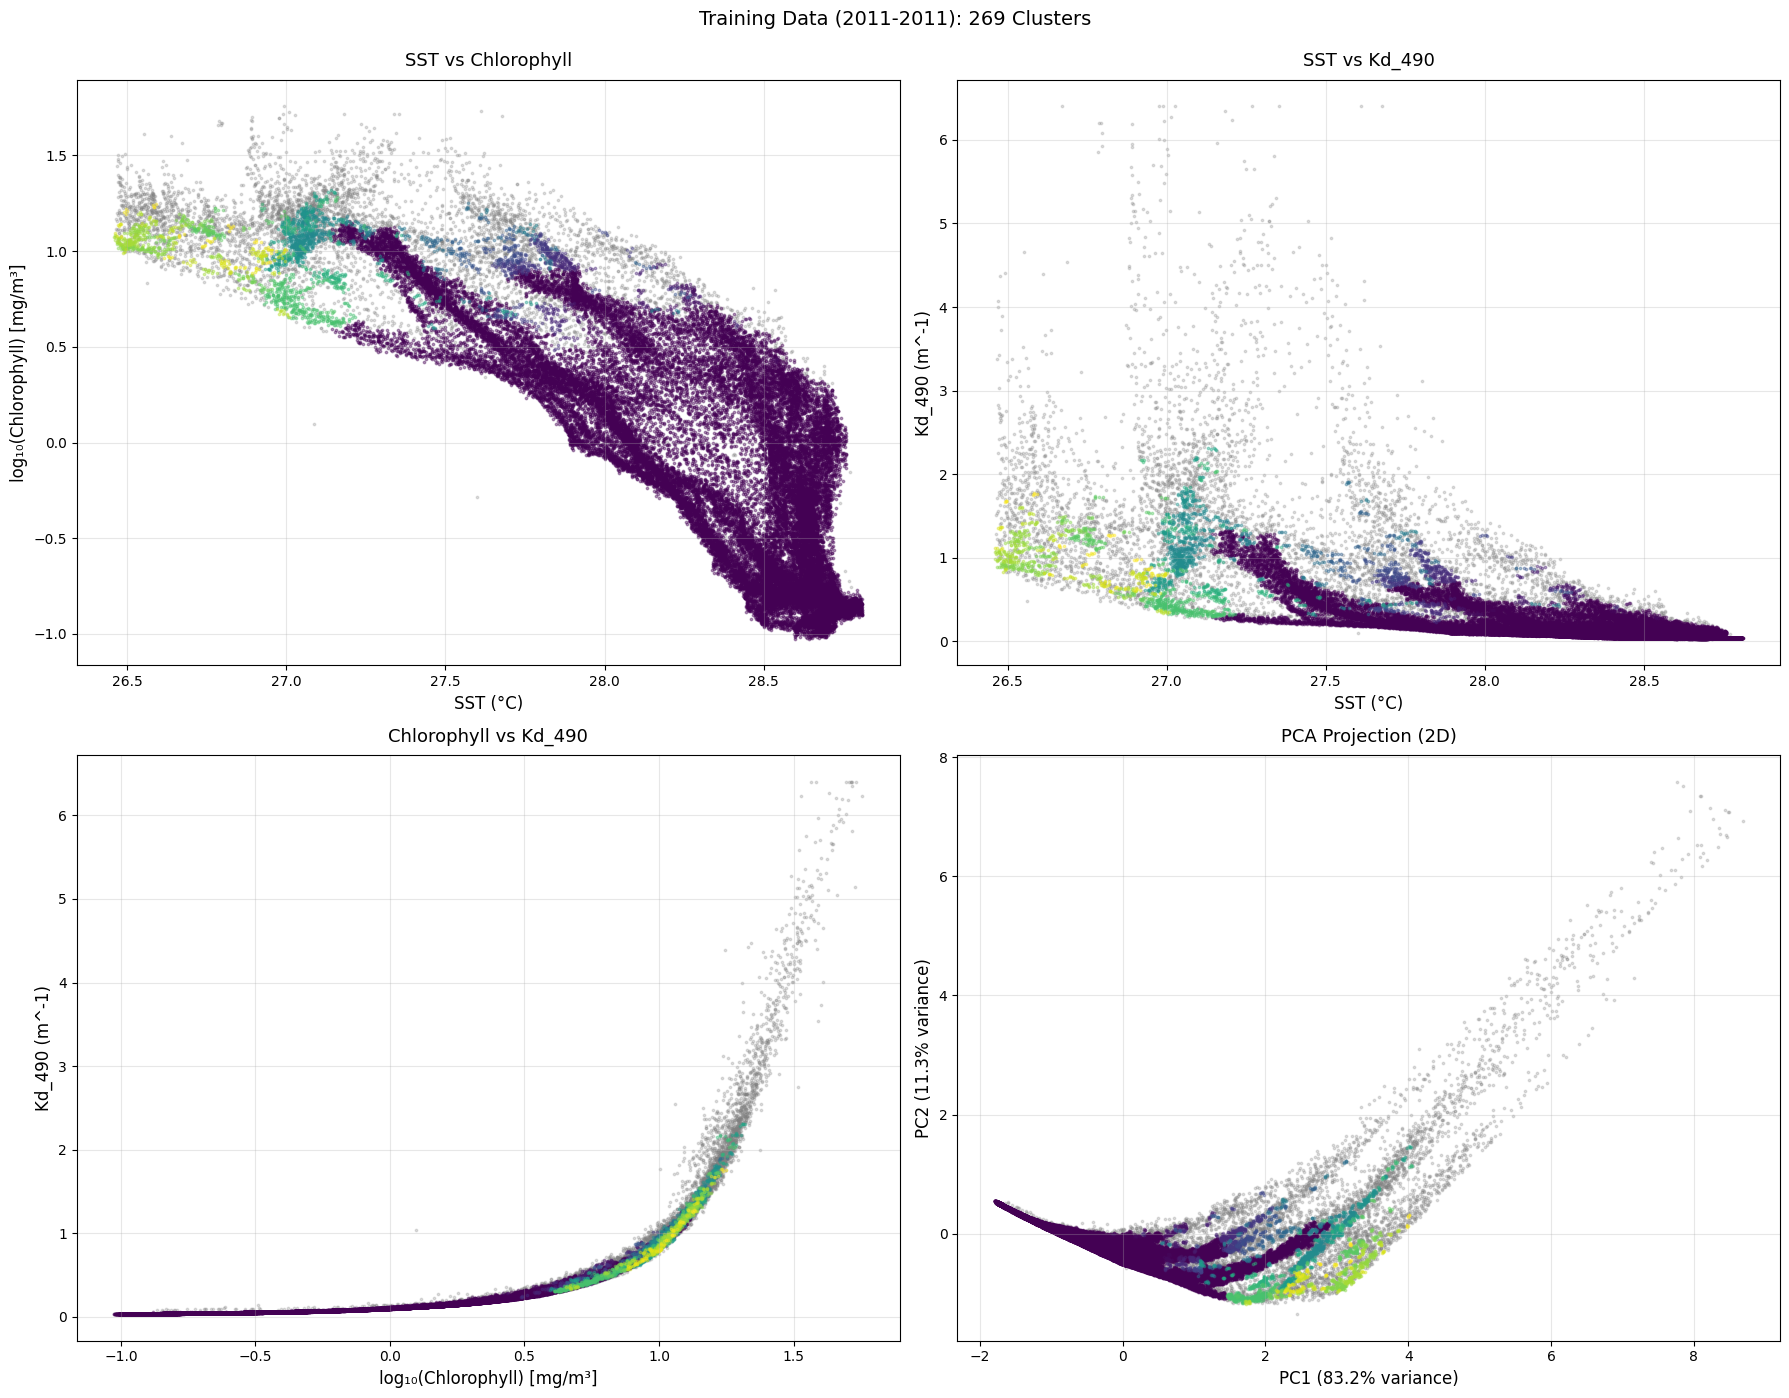

In [101]:
# Visualize feature space: Original 3D projections + PCA 2D projection
fig, axes = plt.subplots(2, 2, figsize=(18, 14))

# Top-left: SST vs log10(Chlorophyll)
for cl in unique_labels:
    mask = training_labels == cl
    color = colors_map.get(cl, '#000000')
    label_text = 'Noise' if cl == -1 else f'Cluster {cl}'
    axes[0,0].scatter(training_sst[mask], np.log10(training_chlor[mask]), 
                      alpha=0.4 if cl != -1 else 0.25, s=3, color=color, label=label_text)

axes[0,0].set_xlabel('SST (°C)', fontsize=12)
axes[0,0].set_ylabel('log₁₀(Chlorophyll) [mg/m³]', fontsize=12)
axes[0,0].set_title('SST vs Chlorophyll', fontsize=13, pad=10)
axes[0,0].grid(True, alpha=0.3)

# Top-right: SST vs Kd_490
for cl in unique_labels:
    mask = training_labels == cl
    color = colors_map.get(cl, '#000000')
    label_text = 'Noise' if cl == -1 else f'Cluster {cl}'
    axes[0,1].scatter(training_sst[mask], training_kd[mask], 
                      alpha=0.4 if cl != -1 else 0.25, s=3, color=color, label=label_text)

axes[0,1].set_xlabel('SST (°C)', fontsize=12)
axes[0,1].set_ylabel('Kd_490 (m^-1)', fontsize=12)
axes[0,1].set_title('SST vs Kd_490', fontsize=13, pad=10)
axes[0,1].grid(True, alpha=0.3)

# Bottom-left: log10(Chlorophyll) vs Kd_490
for cl in unique_labels:
    mask = training_labels == cl
    color = colors_map.get(cl, '#000000')
    label_text = 'Noise' if cl == -1 else f'Cluster {cl}'
    axes[1,0].scatter(np.log10(training_chlor[mask]), training_kd[mask], 
                      alpha=0.4 if cl != -1 else 0.25, s=3, color=color, label=label_text)

axes[1,0].set_xlabel('log₁₀(Chlorophyll) [mg/m³]', fontsize=12)
axes[1,0].set_ylabel('Kd_490 (m^-1)', fontsize=12)
axes[1,0].set_title('Chlorophyll vs Kd_490', fontsize=13, pad=10)
axes[1,0].grid(True, alpha=0.3)

# Bottom-right: PCA projection (2D)
for cl in unique_labels:
    mask = training_labels == cl
    color = colors_map.get(cl, '#000000')
    label_text = 'Noise' if cl == -1 else f'Cluster {cl}'
    axes[1,1].scatter(training_pca[mask, 0], training_pca[mask, 1], 
                      alpha=0.4 if cl != -1 else 0.25, s=3, color=color, label=label_text)

axes[1,1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)', fontsize=12)
axes[1,1].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)', fontsize=12)
axes[1,1].set_title('PCA Projection (2D)', fontsize=13, pad=10)
axes[1,1].grid(True, alpha=0.3)

plt.suptitle(f'Training Data ({training_years[0]}-{training_years[-1]}): {n_clusters} Clusters', 
             fontsize=14, y=0.995)
plt.tight_layout()
plt.show()

In [102]:
# Print detailed cluster statistics
print("\n" + "=" * 80)
print("TRAINING DATA CLUSTER STATISTICS")
print("=" * 80)

for label in sorted(set(training_labels)):
    mask = training_labels == label
    sst_cluster = training_sst[mask]
    chlor_cluster = training_chlor[mask]
    kd_cluster = training_kd[mask]
    
    if label == -1:
        print(f"\n⚪ Noise Points:")
    else:
        print(f"\n🔵 Cluster {label}:")
    
    print(f"  Pixels: {mask.sum():,} ({100*mask.sum()/len(mask):.1f}%)")
    print(f"  SST: {sst_cluster.mean():.2f} ± {sst_cluster.std():.2f} °C")
    print(f"       Range: [{sst_cluster.min():.2f}, {sst_cluster.max():.2f}] °C")
    print(f"  Chlorophyll: {chlor_cluster.mean():.6f} ± {chlor_cluster.std():.6f} mg/m³")
    print(f"               Range: [{chlor_cluster.min():.6f}, {chlor_cluster.max():.6f}] mg/m³")
    print(f"  Kd_490: {kd_cluster.mean():.6f} ± {kd_cluster.std():.6f} m^-1")
    print(f"          Range: [{kd_cluster.min():.6f}, {kd_cluster.max():.6f}] m^-1")

print("\n" + "=" * 80)


TRAINING DATA CLUSTER STATISTICS

⚪ Noise Points:
  Pixels: 5,034 (11.3%)
  SST: 27.35 ± 0.54 °C
       Range: [26.46, 28.77] °C
  Chlorophyll: 12.718773 ± 7.221081 mg/m³
               Range: [0.135826, 56.999141] mg/m³
  Kd_490: 1.398631 ± 1.012782 m^-1
          Range: [0.040463, 6.400000] m^-1

🔵 Cluster 0:
  Pixels: 36,816 (82.4%)
  SST: 28.33 ± 0.39 °C
       Range: [27.14, 28.81] °C
  Chlorophyll: 1.616513 ± 2.232805 mg/m³
               Range: [0.094471, 14.329679] mg/m³
  Kd_490: 0.151153 ± 0.185779 m^-1
          Range: [0.031516, 1.336911] m^-1

🔵 Cluster 1:
  Pixels: 4 (0.0%)
  SST: 28.52 ± 0.01 °C
       Range: [28.50, 28.54] °C
  Chlorophyll: 2.471947 ± 0.009245 mg/m³
               Range: [2.459226, 2.482594] mg/m³
  Kd_490: 0.261260 ± 0.006512 m^-1
          Range: [0.250129, 0.266652] m^-1

🔵 Cluster 2:
  Pixels: 7 (0.0%)
  SST: 28.53 ± 0.01 °C
       Range: [28.52, 28.55] °C
  Chlorophyll: 3.424009 ± 0.062208 mg/m³
               Range: [3.337364, 3.536757] mg/m³
  K

## 4. Apply Model to New Data

Select a time period to apply the trained clustering model.

**Note on Data Coverage:**
- SST data (L4) provides complete daily coverage
- Chlorophyll & Kd_490 data (from L2 MODIS) only available along satellite swaths
- Cloud cover creates gaps in optical data
- Weekly averages use all available observations (not requiring 7 days)
- Clustering only applied where all 3 features are available

In [103]:
# Configuration for new data
apply_year = 2009
apply_start = '2009-07-01'
apply_end = '2009-07-31'

sst_var = 'analysed_sst'
chlor_var = 'chlor_a'
chlor_group = 'geophysical_data'

sst_base_pattern = r"E:\satdata\MUR-JPL-L4-GLOB-v4.1_Texas Louisiana Shelf_{year}-06-01_{year}-11-30"
chlor_base_pattern = r"E:\satdata\Texas Louisiana Shelf_{year}-06-01_{year}-11-30"

print(f"Applying model to: {apply_start} to {apply_end}")

Applying model to: 2009-07-01 to 2009-07-31


In [104]:
# Load SST data for the period
print("\n" + "=" * 80)
print("LOADING SST DATA")
print("=" * 80)

sst_dir = sst_base_pattern.format(year=apply_year)
all_sst_files = sorted(glob.glob(os.path.join(sst_dir, '*.nc')))
print(f"  Total SST files in {apply_year}: {len(all_sst_files)}")

# Filter by date
sst_files = []
for sst_file in all_sst_files:
    try:
        with xr.open_dataset(sst_file) as ds:
            file_time = pd.to_datetime(ds.time.values[0])
            if pd.Timestamp(apply_start) <= file_time <= pd.Timestamp(apply_end):
                sst_files.append(sst_file)
    except:
        continue

print(f"  Files in period: {len(sst_files)}")

# Load datasets
sst_loader = L3DatasetLoader(variables=[sst_var], bbox=(lon_min, lon_max, lat_min, lat_max))
sst_datasets = sst_loader.load_multiple(sst_files)

# Process SST
sst_list = []
for ds in sst_datasets:
    sst_k = ds[sst_var].values.squeeze()
    sst_c = sst_k - 273.15
    sst_c[(sst_c < -2) | (sst_c > 35)] = np.nan
    sst_list.append(sst_c)

sst_mean = np.nanmean(np.stack(sst_list, axis=0), axis=0)
lat_sst = sst_datasets[0]['lat'].values
lon_sst = sst_datasets[0]['lon'].values

print(f"  SST range: {np.nanmin(sst_mean):.2f} to {np.nanmax(sst_mean):.2f} °C")
print(f"  Valid pixels: {np.sum(~np.isnan(sst_mean))}")


LOADING SST DATA
  Total SST files in 2009: 184
  Files in period: 30
  Files in period: 30
  SST range: 28.15 to 30.42 °C
  Valid pixels: 137002
  SST range: 28.15 to 30.42 °C
  Valid pixels: 137002


In [105]:
# Load chlorophyll data for the period
print("\n" + "=" * 80)
print("LOADING CHLOROPHYLL DATA")
print("=" * 80)

chlor_dir = chlor_base_pattern.format(year=apply_year)
all_chlor_files = glob.glob(os.path.join(chlor_dir, '**', '*.nc'), recursive=True)
print(f"  Total chlorophyll files in {apply_year}: {len(all_chlor_files)}")

# Filter by date (from filename)
chlor_files = []
for chlor_file in all_chlor_files:
    filename = os.path.basename(chlor_file)
    try:
        if 'AQUA_MODIS' in filename or 'MODIS' in filename:
            parts = filename.split('.')
            if len(parts) > 1:
                date_str = parts[1][:8]
                file_date = pd.to_datetime(date_str, format='%Y%m%d')
                if pd.Timestamp(apply_start) <= file_date <= pd.Timestamp(apply_end):
                    chlor_files.append(chlor_file)
    except:
        continue

print(f"  Files in period: {len(chlor_files)}")

if len(chlor_files) > 0:
    # Load datasets
    chlor_loader = L2DatasetLoader(variables=[chlor_var], group=chlor_group)
    chlor_datasets = chlor_loader.load_multiple(chlor_files)
    
    # Extract data
    try:
        extractor = GPUDataExtractor(variables=[chlor_var])
        lon_chlor, lat_chlor, chlor_data = extractor.extract(chlor_datasets)
        chlor_flat = chlor_data[chlor_var]
        print(f"  GPU extraction: {len(chlor_flat)} points")
    except Exception as e:
        print(f"  GPU failed, using CPU...")
        all_lons, all_lats, all_chlor = [], [], []
        for ds in chlor_datasets:
            lat = ds['lat'].values.flatten()
            lon = ds['lon'].values.flatten()
            chlor = ds[chlor_var].values.flatten()
            valid = (~np.isnan(lat) & ~np.isnan(lon) & ~np.isnan(chlor) & (chlor > 0))
            all_lats.extend(lat[valid])
            all_lons.extend(lon[valid])
            all_chlor.extend(chlor[valid])
        lat_chlor = np.array(all_lats)
        lon_chlor = np.array(all_lons)
        chlor_flat = np.array(all_chlor)
        print(f"  CPU extraction: {len(chlor_flat)} points")
else:
    print("  ⚠ No chlorophyll files found")
    chlor_flat = np.array([])
    lat_chlor = np.array([])
    lon_chlor = np.array([])


LOADING CHLOROPHYLL DATA
  Total chlorophyll files in 2009: 284
  Files in period: 50
  GPU extraction: 14552214 points
  GPU extraction: 14552214 points


In [106]:
# Load Kd_490 data
print("\n" + "=" * 80)
print("LOADING KD_490 DATA")
print("=" * 80)

if len(chlor_files) > 0:
    # Load Kd_490 datasets (same files as chlorophyll)
    kd_loader = L2DatasetLoader(variables=[kd_var], group=chlor_group)
    kd_datasets = kd_loader.load_multiple(chlor_files)
    
    # Extract Kd_490 data
    try:
        kd_extractor = GPUDataExtractor(variables=[kd_var])
        lon_kd, lat_kd, kd_data = kd_extractor.extract(kd_datasets)
        kd_flat = kd_data[kd_var]
        print(f"  GPU extraction: {len(kd_flat)} points")
    except Exception as e:
        print(f"  GPU failed, using CPU...")
        all_lons, all_lats, all_kd = [], [], []
        for ds in kd_datasets:
            lat = ds['lat'].values.flatten()
            lon = ds['lon'].values.flatten()
            kd = ds[kd_var].values.flatten()
            valid = (~np.isnan(lat) & ~np.isnan(lon) & ~np.isnan(kd) & (kd > 0))
            all_lats.extend(lat[valid])
            all_lons.extend(lon[valid])
            all_kd.extend(kd[valid])
        lat_kd = np.array(all_lats)
        lon_kd = np.array(all_lons)
        kd_flat = np.array(all_kd)
        print(f"  CPU extraction: {len(kd_flat)} points")
    
    print(f"  Kd_490 range: {np.nanmin(kd_flat):.4f} to {np.nanmax(kd_flat):.4f} m^-1")
    print(f"  Valid Kd_490 points: {np.sum(~np.isnan(kd_flat))}")
else:
    print("  ⚠ No Kd_490 files found")
    kd_flat = np.array([])
    lat_kd = np.array([])
    lon_kd = np.array([])


LOADING KD_490 DATA
  GPU extraction: 14558585 points
  Kd_490 range: 0.0166 to 6.4000 m^-1
  Valid Kd_490 points: 14558585
  GPU extraction: 14558585 points
  Kd_490 range: 0.0166 to 6.4000 m^-1
  Valid Kd_490 points: 14558585


In [107]:
# Grid the data - improved averaging strategy
print("\n" + "=" * 80)
print("GRIDDING DATA (WITH FLEXIBLE AVERAGING)")
print("=" * 80)

# Bin chlorophyll with count tracking
if len(chlor_flat) > 0:
    clip_mask = ((lon_chlor >= lon_min) & (lon_chlor <= lon_max) &
                 (lat_chlor >= lat_min) & (lat_chlor <= lat_max))

    # Mean of available data points
    chlor_binned, _, _, _ = binned_statistic_2d(
        lat_chlor[clip_mask], lon_chlor[clip_mask], chlor_flat[clip_mask],
        statistic='mean',
        bins=[lat_bins, lon_bins],
        range=[[lat_min, lat_max], [lon_min, lon_max]]
    )
    
    # Count of data points per bin
    chlor_count, _, _, _ = binned_statistic_2d(
        lat_chlor[clip_mask], lon_chlor[clip_mask], chlor_flat[clip_mask],
        statistic='count',
        bins=[lat_bins, lon_bins],
        range=[[lat_min, lat_max], [lon_min, lon_max]]
    )
    
    print(f"  Valid chlorophyll pixels: {np.sum(~np.isnan(chlor_binned))}")
    print(f"  Average observations per pixel: {np.nanmean(chlor_count[chlor_count > 0]):.1f}")
    print(f"  Max observations per pixel: {np.nanmax(chlor_count):.0f}")
else:
    chlor_binned = np.full((lat_bins, lon_bins), np.nan)
    chlor_count = np.zeros((lat_bins, lon_bins))
    print("  No chlorophyll data to grid")

# Bin Kd_490 with count tracking
if len(kd_flat) > 0:
    clip_mask_kd = ((lon_kd >= lon_min) & (lon_kd <= lon_max) &
                    (lat_kd >= lat_min) & (lat_kd <= lat_max))

    # Mean of available data points
    kd_binned, _, _, _ = binned_statistic_2d(
        lat_kd[clip_mask_kd], lon_kd[clip_mask_kd], kd_flat[clip_mask_kd],
        statistic='mean',
        bins=[lat_bins, lon_bins],
        range=[[lat_min, lat_max], [lon_min, lon_max]]
    )
    
    # Count of data points per bin
    kd_count, _, _, _ = binned_statistic_2d(
        lat_kd[clip_mask_kd], lon_kd[clip_mask_kd], kd_flat[clip_mask_kd],
        statistic='count',
        bins=[lat_bins, lon_bins],
        range=[[lat_min, lat_max], [lon_min, lon_max]]
    )
    
    print(f"  Valid Kd_490 pixels: {np.sum(~np.isnan(kd_binned))}")
    print(f"  Average observations per pixel: {np.nanmean(kd_count[kd_count > 0]):.1f}")
    print(f"  Max observations per pixel: {np.nanmax(kd_count):.0f}")
else:
    kd_binned = np.full((lat_bins, lon_bins), np.nan)
    kd_count = np.zeros((lat_bins, lon_bins))
    print("  No Kd_490 data to grid")

# Interpolate SST
sst_interpolator = RegularGridInterpolator(
    (lat_sst, lon_sst), sst_mean,
    method='linear', bounds_error=False, fill_value=np.nan
)

lon_grid, lat_grid = np.meshgrid(lon_centers, lat_centers)
points = np.column_stack([lat_grid.ravel(), lon_grid.ravel()])
sst_regridded = sst_interpolator(points).reshape(chlor_binned.shape)

print(f"  Valid SST pixels: {np.sum(~np.isnan(sst_regridded))}")

# Summary statistics
print(f"\n  Combined coverage:")
overlap_mask = ~np.isnan(sst_regridded) & ~np.isnan(chlor_binned) & ~np.isnan(kd_binned)
print(f"  Pixels with all 3 features: {np.sum(overlap_mask)} ({100*np.sum(overlap_mask)/(lat_bins*lon_bins):.1f}%)")
print(f"  Note: Averages are computed from available observations only (not fixed 7-day period)")


GRIDDING DATA (WITH FLEXIBLE AVERAGING)
  Valid chlorophyll pixels: 44164
  Average observations per pixel: 10.9
  Max observations per pixel: 30
  Valid chlorophyll pixels: 44164
  Average observations per pixel: 10.9
  Max observations per pixel: 30
  Valid Kd_490 pixels: 44195
  Average observations per pixel: 10.9
  Max observations per pixel: 30
  Valid SST pixels: 44898

  Combined coverage:
  Pixels with all 3 features: 43721 (72.9%)
  Note: Averages are computed from available observations only (not fixed 7-day period)
  Valid Kd_490 pixels: 44195
  Average observations per pixel: 10.9
  Max observations per pixel: 30
  Valid SST pixels: 44898

  Combined coverage:
  Pixels with all 3 features: 43721 (72.9%)
  Note: Averages are computed from available observations only (not fixed 7-day period)


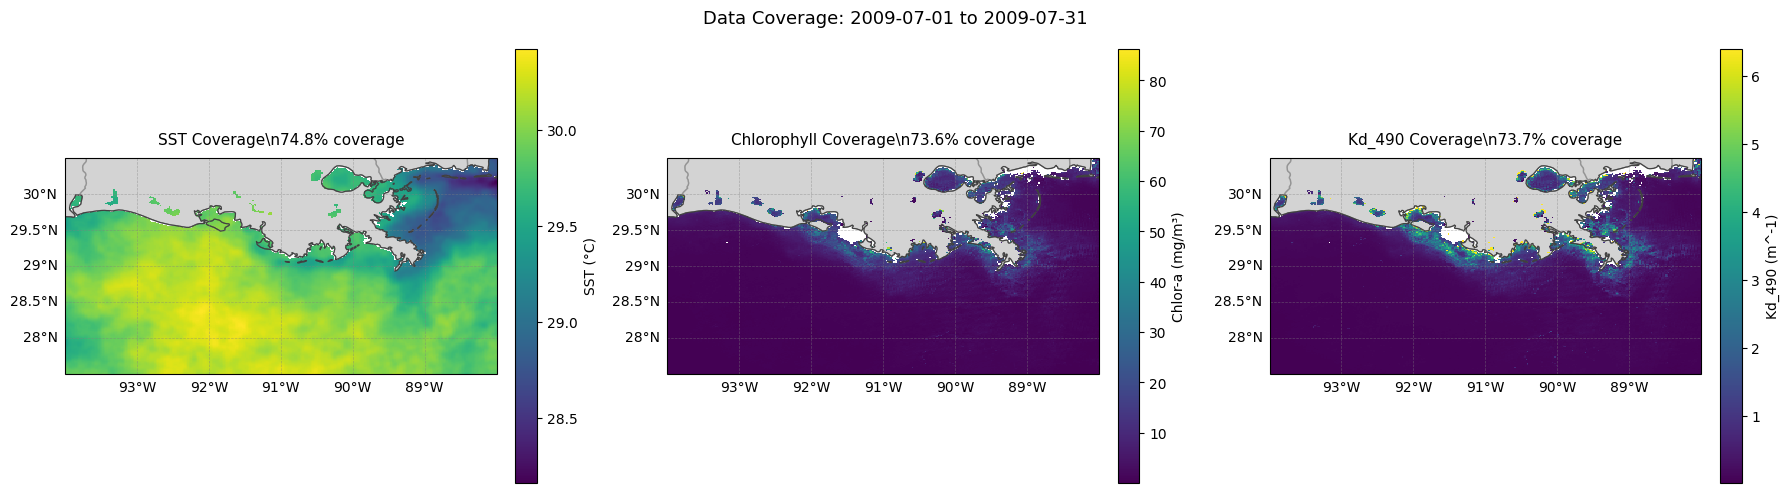

\nGap Analysis:
  White areas in chlorophyll/Kd_490 maps = no satellite observations (clouds/swath gaps)
  Clustering requires all 3 features, so uses intersection of coverage areas


In [108]:
# Visualize data coverage to understand gaps
if len(chlor_flat) > 0 or len(kd_flat) > 0:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5), subplot_kw={'projection': ccrs.PlateCarree()})
    
    for idx, (data, title, cbar_label) in enumerate([
        (sst_regridded, 'SST Coverage', 'SST (°C)'),
        (chlor_binned, 'Chlorophyll Coverage', 'Chlor-a (mg/m³)'),
        (kd_binned, 'Kd_490 Coverage', 'Kd_490 (m^-1)')
    ]):
        ax = axes[idx]
        ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())
        
        # Plot data coverage
        im = ax.pcolormesh(lon_edges, lat_edges, data,
                          cmap='viridis', shading='auto',
                          transform=ccrs.PlateCarree())
        
        ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
        ax.add_feature(cfeature.LAND, facecolor='lightgray')
        ax.add_feature(cfeature.STATES, linestyle='-', edgecolor='gray', alpha=0.5)
        
        gl = ax.gridlines(draw_labels=True, linewidth=0.5, color='gray', alpha=0.5, linestyle='--')
        gl.top_labels = gl.right_labels = False
        
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label=cbar_label)
        
        coverage_pct = 100 * np.sum(~np.isnan(data)) / data.size
        ax.set_title(f'{title}\\n{coverage_pct:.1f}% coverage', fontsize=11, pad=10)
    
    plt.suptitle(f'Data Coverage: {apply_start} to {apply_end}', fontsize=13, y=0.98)
    plt.tight_layout()
    plt.show()
    
    print(f"\\nGap Analysis:")
    print(f"  White areas in chlorophyll/Kd_490 maps = no satellite observations (clouds/swath gaps)")
    print(f"  Clustering requires all 3 features, so uses intersection of coverage areas")

In [109]:
# Apply clustering model
print("\n" + "=" * 80)
print("APPLYING CLUSTERING MODEL")
print("=" * 80)

valid_mask = (~np.isnan(sst_regridded) & ~np.isnan(chlor_binned) & ~np.isnan(kd_binned) &
              np.isfinite(sst_regridded) & np.isfinite(chlor_binned) & np.isfinite(kd_binned) &
              (kd_binned > 0))
n_valid = np.sum(valid_mask)
print(f"  Pixels with SST, chlorophyll, and Kd_490: {n_valid}")

if n_valid > 0:
    sst_valid = sst_regridded[valid_mask]
    chlor_valid = chlor_binned[valid_mask]
    kd_valid = kd_binned[valid_mask]
    
    # Create features (same as training)
    features = np.column_stack([sst_valid, np.log10(chlor_valid), kd_valid])
    
    # Check for non-finite values
    finite_mask = np.all(np.isfinite(features), axis=1)
    if not np.all(finite_mask):
        print(f"  Removing {np.sum(~finite_mask)} rows with non-finite values")
        features = features[finite_mask]
        sst_valid = sst_valid[finite_mask]
        chlor_valid = chlor_valid[finite_mask]
        kd_valid = kd_valid[finite_mask]
        valid_mask_indices = np.where(valid_mask)[0][finite_mask]
    
    features_scaled = scaler.transform(features)
    
    # Predict clusters
    labels = dbscan.fit_predict(features_scaled)
    
    n_clusters_found = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = np.sum(labels == -1)
    
    print(f"  Clusters found: {n_clusters_found}")
    print(f"  Noise points: {n_noise} ({100*n_noise/len(labels):.1f}%)")
    
    # Create cluster map
    cluster_map = np.full(sst_regridded.shape, np.nan)
    cluster_map[valid_mask] = labels
else:
    print("  ⚠ No valid data to cluster")
    labels = np.array([])
    cluster_map = np.full(sst_regridded.shape, np.nan)


APPLYING CLUSTERING MODEL
  Pixels with SST, chlorophyll, and Kd_490: 43721
  Clusters found: 371
  Noise points: 7096 (16.2%)
  Clusters found: 371
  Noise points: 7096 (16.2%)


## 5. Visualize Results

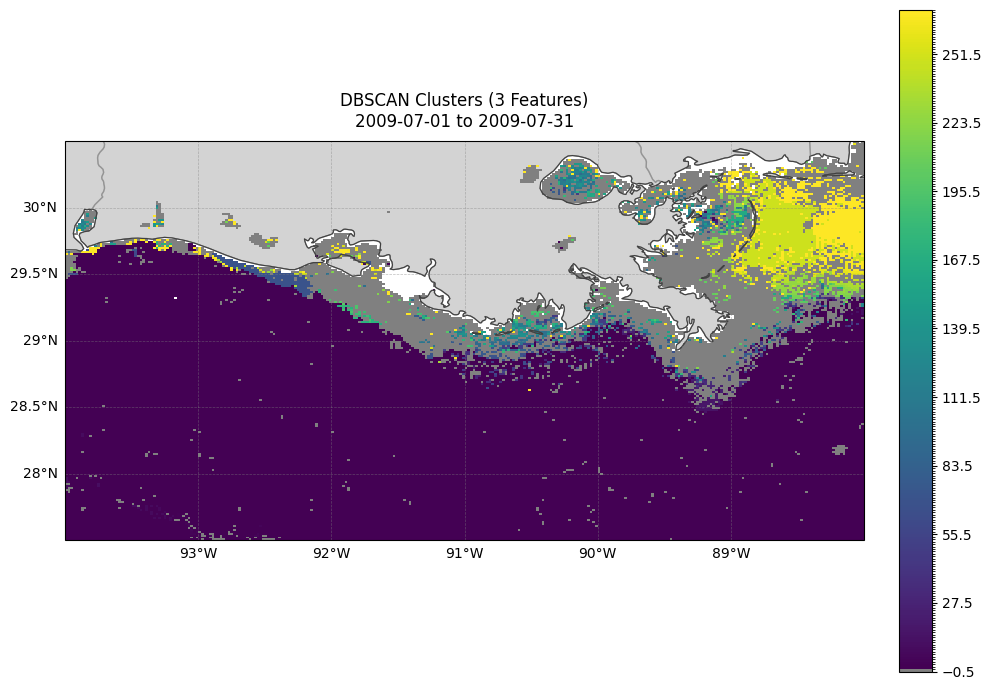

In [110]:
if n_valid > 0:
    fig, ax = plt.subplots(1, 1, figsize=(10, 7), subplot_kw={'projection': ccrs.PlateCarree()})

    # Prepare plot data
    unique_labels_new = sorted(set(labels))
    cluster_labels_new = [l for l in unique_labels_new if l != -1]
    cluster_labels_sorted_new = sorted(cluster_labels_new)

    plot_map = np.full_like(cluster_map, np.nan)
    if len(cluster_labels_sorted_new) > 0:
        plot_map[valid_mask] = np.where(
            labels == -1, 0,
            np.array([cluster_labels_sorted_new.index(l) + 1 if l in cluster_labels_sorted_new else 0 
                      for l in labels])
        )

    # Cluster map
    ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())

    cluster_plot = ax.pcolormesh(lon_edges, lat_edges, plot_map,
                                 cmap=cmap, norm=norm, shading='auto',
                                 transform=ccrs.PlateCarree())

    ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
    ax.add_feature(cfeature.LAND, facecolor='lightgray')
    ax.add_feature(cfeature.STATES, linestyle='-', edgecolor='gray', alpha=0.5)

    gl = ax.gridlines(draw_labels=True, linewidth=0.5, color='gray', alpha=0.5, linestyle='--')
    gl.top_labels = gl.right_labels = False

    plt.colorbar(cluster_plot, ax=ax, fraction=0.046, pad=0.04)
    ax.set_title(f'DBSCAN Clusters (3 Features)\n{apply_start} to {apply_end}', fontsize=12, pad=10)

    plt.tight_layout()
    plt.show()
else:
    print("No data to visualize")

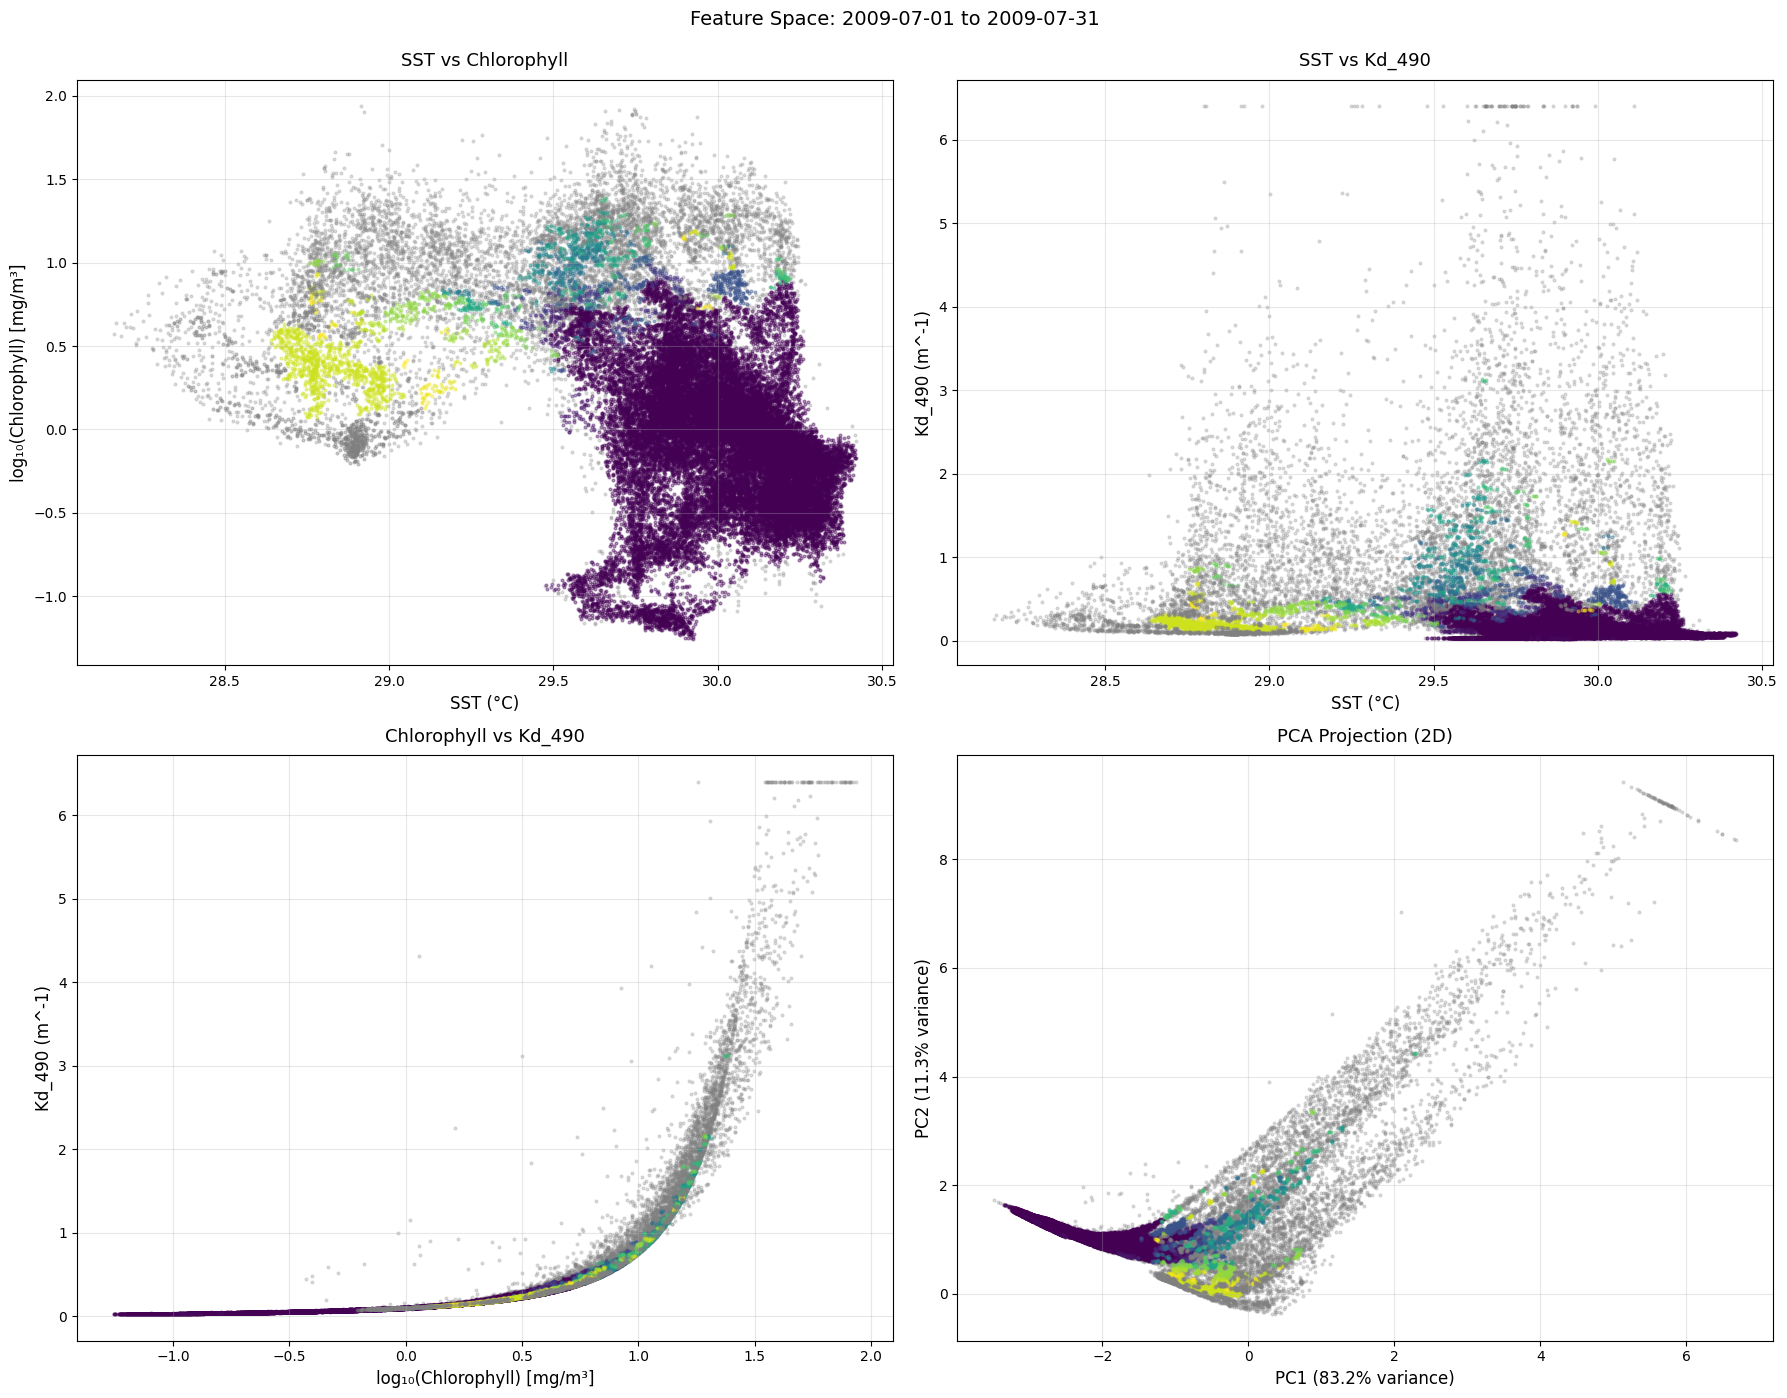

In [111]:
# Feature space for new data with PCA
if n_valid > 0:
    # Apply PCA to new data
    new_pca = pca.transform(features_scaled)
    
    fig, axes = plt.subplots(2, 2, figsize=(18, 14))
    
    # Top-left: SST vs log10(Chlorophyll)
    for cl in unique_labels_new:
        mask = labels == cl
        color = colors_map.get(cl, '#808080')
        label_text = 'Noise' if cl == -1 else f'Cluster {cl}'
        axes[0,0].scatter(sst_valid[mask], np.log10(chlor_valid[mask]), 
                          alpha=0.4 if cl != -1 else 0.25, s=4, color=color, label=label_text)
    
    axes[0,0].set_xlabel('SST (°C)', fontsize=12)
    axes[0,0].set_ylabel('log₁₀(Chlorophyll) [mg/m³]', fontsize=12)
    axes[0,0].set_title('SST vs Chlorophyll', fontsize=13, pad=10)
    axes[0,0].grid(True, alpha=0.3)
    
    # Top-right: SST vs Kd_490
    for cl in unique_labels_new:
        mask = labels == cl
        color = colors_map.get(cl, '#808080')
        label_text = 'Noise' if cl == -1 else f'Cluster {cl}'
        axes[0,1].scatter(sst_valid[mask], kd_valid[mask], 
                          alpha=0.4 if cl != -1 else 0.25, s=4, color=color, label=label_text)
    
    axes[0,1].set_xlabel('SST (°C)', fontsize=12)
    axes[0,1].set_ylabel('Kd_490 (m^-1)', fontsize=12)
    axes[0,1].set_title('SST vs Kd_490', fontsize=13, pad=10)
    axes[0,1].grid(True, alpha=0.3)
    
    # Bottom-left: log10(Chlorophyll) vs Kd_490
    for cl in unique_labels_new:
        mask = labels == cl
        color = colors_map.get(cl, '#808080')
        label_text = 'Noise' if cl == -1 else f'Cluster {cl}'
        axes[1,0].scatter(np.log10(chlor_valid[mask]), kd_valid[mask], 
                          alpha=0.4 if cl != -1 else 0.25, s=4, color=color, label=label_text)
    
    axes[1,0].set_xlabel('log₁₀(Chlorophyll) [mg/m³]', fontsize=12)
    axes[1,0].set_ylabel('Kd_490 (m^-1)', fontsize=12)
    axes[1,0].set_title('Chlorophyll vs Kd_490', fontsize=13, pad=10)
    axes[1,0].grid(True, alpha=0.3)
    
    # Bottom-right: PCA projection (2D)
    for cl in unique_labels_new:
        mask = labels == cl
        color = colors_map.get(cl, '#808080')
        label_text = 'Noise' if cl == -1 else f'Cluster {cl}'
        axes[1,1].scatter(new_pca[mask, 0], new_pca[mask, 1], 
                          alpha=0.4 if cl != -1 else 0.25, s=4, color=color, label=label_text)
    
    axes[1,1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)', fontsize=12)
    axes[1,1].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)', fontsize=12)
    axes[1,1].set_title('PCA Projection (2D)', fontsize=13, pad=10)
    axes[1,1].grid(True, alpha=0.3)
    
    plt.suptitle(f'Feature Space: {apply_start} to {apply_end}', fontsize=14, y=0.995)
    plt.tight_layout()
    plt.show()

In [112]:
# Print cluster statistics for new data
if n_valid > 0:
    print("\n" + "=" * 80)
    print(f"CLUSTER STATISTICS: {apply_start.upper()} TO {apply_end.upper()}")
    print("=" * 80)
    
    for label in sorted(set(labels)):
        mask = labels == label
        sst_cluster = sst_valid[mask]
        chlor_cluster = chlor_valid[mask]
        kd_cluster = kd_valid[mask]
        
        if label == -1:
            print(f"\n⚪ Noise Points:")
        else:
            print(f"\n🔵 Cluster {label}:")
        
        print(f"  Pixels: {mask.sum():,} ({100*mask.sum()/len(mask):.1f}%)")
        print(f"  SST: {sst_cluster.mean():.2f} ± {sst_cluster.std():.2f} °C")
        print(f"       Range: [{sst_cluster.min():.2f}, {sst_cluster.max():.2f}] °C")
        print(f"  Chlorophyll: {chlor_cluster.mean():.6f} ± {chlor_cluster.std():.6f} mg/m³")
        print(f"               Range: [{chlor_cluster.min():.6f}, {chlor_cluster.max():.6f}] mg/m³")
        print(f"  Kd_490: {kd_cluster.mean():.6f} ± {kd_cluster.std():.6f} m^-1")
        print(f"          Range: [{kd_cluster.min():.6f}, {kd_cluster.max():.6f}] m^-1")
    
    print("\n" + "=" * 80)


CLUSTER STATISTICS: 2009-07-01 TO 2009-07-31

⚪ Noise Points:
  Pixels: 7,096 (16.2%)
  SST: 29.46 ± 0.46 °C
       Range: [28.16, 30.42] °C
  Chlorophyll: 12.306901 ± 9.041218 mg/m³
               Range: [0.068339, 86.311951] mg/m³
  Kd_490: 1.315821 ± 1.153622 m^-1
          Range: [0.029800, 6.400000] m^-1

🔵 Cluster 0:
  Pixels: 32,619 (74.6%)
  SST: 30.03 ± 0.19 °C
       Range: [29.49, 30.42] °C
  Chlorophyll: 1.175248 ± 1.157140 mg/m³
               Range: [0.055742, 7.963255] mg/m³
  Kd_490: 0.114312 ± 0.080679 m^-1
          Range: [0.028125, 0.654415] m^-1

🔵 Cluster 1:
  Pixels: 7 (0.0%)
  SST: 29.99 ± 0.01 °C
       Range: [29.97, 30.01] °C
  Chlorophyll: 0.132678 ± 0.003536 mg/m³
               Range: [0.127931, 0.137299] mg/m³
  Kd_490: 0.038103 ± 0.000776 m^-1
          Range: [0.037156, 0.039200] m^-1

🔵 Cluster 2:
  Pixels: 8 (0.0%)
  SST: 30.00 ± 0.01 °C
       Range: [29.99, 30.01] °C
  Chlorophyll: 0.158691 ± 0.003971 mg/m³
               Range: [0.153320, 0.165915

## 6. Summary

The trained DBSCAN model with **3 features** (SST, Chlorophyll, Kd_490) can identify oceanic regimes based on these combined patterns. The model was trained on 2010-2011 data and can be applied to any new time period with SST, chlorophyll, and Kd_490 measurements.

**Key Features:**
- Uses Kd_490 (Diffuse attenuation coefficient at 490 nm) directly from MODIS L2 data
- PCA projection helps visualize the 3D feature space in 2D
- All three features contribute to defining distinct water mass types

**Next Steps:**
- Apply to different time periods
- Compare 3-feature clusters with 2-feature results
- Analyze how Kd_490 improves cluster separation
- Export cluster masks for further analysis